# Module Imports and Notebook Settings


In [81]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import googlemaps
from ares import logger
import os
from pathlib import Path
from dotenv import load_dotenv
from ares.utils.common import load_json, save_json
import warnings

load_dotenv()

warnings.filterwarnings("ignore")

%matplotlib inline
mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["figure.edgecolor"] = "black"
mpl.rcParams["axes.linewidth"] = 0.5

sns.set()
rc = {
    "font.family": ["serif"],
    "font.serif": "Times New Roman",
    "grid.color": "gainsboro",
    "grid.linestyle": "-",
}
sns.set_style(rc=rc)
sns.set_context("notebook", font_scale=0.8)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)


# Artefacts Loading


In [82]:
df = pd.read_csv("../artifacts/data/01-raw/untouched_raw_original.csv")
train_df = pd.read_csv("../artifacts/data/01-raw/train_df.csv")
eval_df = pd.read_csv("../artifacts/data/01-raw/eval_df.csv")
geocode_path = Path("../artifacts/data/04-geocode_cache/geocode_cache.json")
maps = googlemaps.Client(key=os.getenv("GOOGLE_MAPS_KEY"))

[2026-01-11 12:14:21,494: INFO: client: API queries_quota: 60]


In [83]:
print(train_df.shape)
print(eval_df.shape)

(12538, 30)
(3135, 30)


# Geocode localities


In [84]:
def geocode(x):
    """Geocode a location x using Google Maps API"""
    try:
        result = maps.geocode(x.lower(), region="gh")
        if result:
            lat = result[0]["geometry"]["location"]["lat"]
            lng = result[0]["geometry"]["location"]["lng"]
            return (lat, lng)
    except Exception as e:
        logger.info(f"Error geocoding {x}: {e}")
    return (None, None)


def create_cache(df):
    """Save geocode data as json"""
    cache = {}
    locs = df["loc"].unique()
    for i, loc in enumerate(locs, 1):
        lat, lng = geocode(loc)
        cache[loc] = {"lat": lat, "lng": lng}

    save_json(geocode_path, cache)
    return cache


try:
    geocodes_cache = load_json(geocode_path)
except FileNotFoundError:
    geocode_path.parent.mkdir(parents=True, exist_ok=True)
    geocodes_cache = create_cache(df)


def get_lat_lng(location):
    """Fetch the latitude and longitude of a location"""
    location_lower = location.lower()
    if location_lower in geocodes_cache:
        result = geocodes_cache[location_lower]
        return (result["lat"], result["lng"])
    else:
        lat, lng = geocode(location_lower)
        geocodes_cache[location_lower] = {"lat": lat, "lng": lng}
        save_json(geocode_path, geocodes_cache)
        return (lat, lng)


[2026-01-11 12:14:21,531: INFO: common: JSON file loaded successfully from: ../artifacts/data/04-geocode_cache/geocode_cache.json]


In [85]:
train_df[["lat", "lng"]] = train_df["loc"].apply(lambda x: pd.Series(get_lat_lng(x)))
eval_df[["lat", "lng"]] = eval_df["loc"].apply(lambda x: pd.Series(get_lat_lng(x)))

In [86]:
missing_train = train_df[train_df["lat"].isnull()]["loc"].unique()
missing_eval = eval_df[eval_df["lat"].isnull()]["loc"].unique()

logger.warning(
    f"Train data still missing {len(missing_train)} lat/lng for: {missing_train}"
)
logger.warning(
    f"Eval data still missing {len(missing_eval)} lat/lng for: {missing_eval}"
)


[2026-01-11 12:14:22,869: WARNING: 2347945726: Train data still missing 0 lat/lng for: []]
[2026-01-11 12:14:22,871: WARNING: 2347945726: Eval data still missing 0 lat/lng for: []]


# Handling Duplicates


In [87]:
train_df = train_df.drop_duplicates(subset="url")
eval_df = eval_df.drop_duplicates(subset="url")

# Handling Price Outliers


In [88]:
train_df["price"].describe()

count    1.253800e+04
mean     6.669313e+04
std      3.280765e+06
min      1.600000e+02
25%      2.200000e+03
50%      4.500000e+03
75%      1.275000e+04
max      2.788467e+08
Name: price, dtype: float64

In [89]:
x = np.log(train_df["price"])
q1, q3 = np.percentile(x, [25, 75])
iqr = q3 - q1
l1 = q1 - 1.5 * iqr
l2 = q3 + 1.5 * iqr

print(f"Lower bound (log): {l1:.4f}")
print(f"Upper bound (log): {l2:.4f}")
print(f"Lower bound (original): {np.exp(l1):.2f}")
print(f"Upper bound (original): {np.exp(l2):.2f}")

Lower bound (log): 5.0606
Upper bound (log): 12.0889
Lower bound (original): 157.69
Upper bound (original): 177885.87


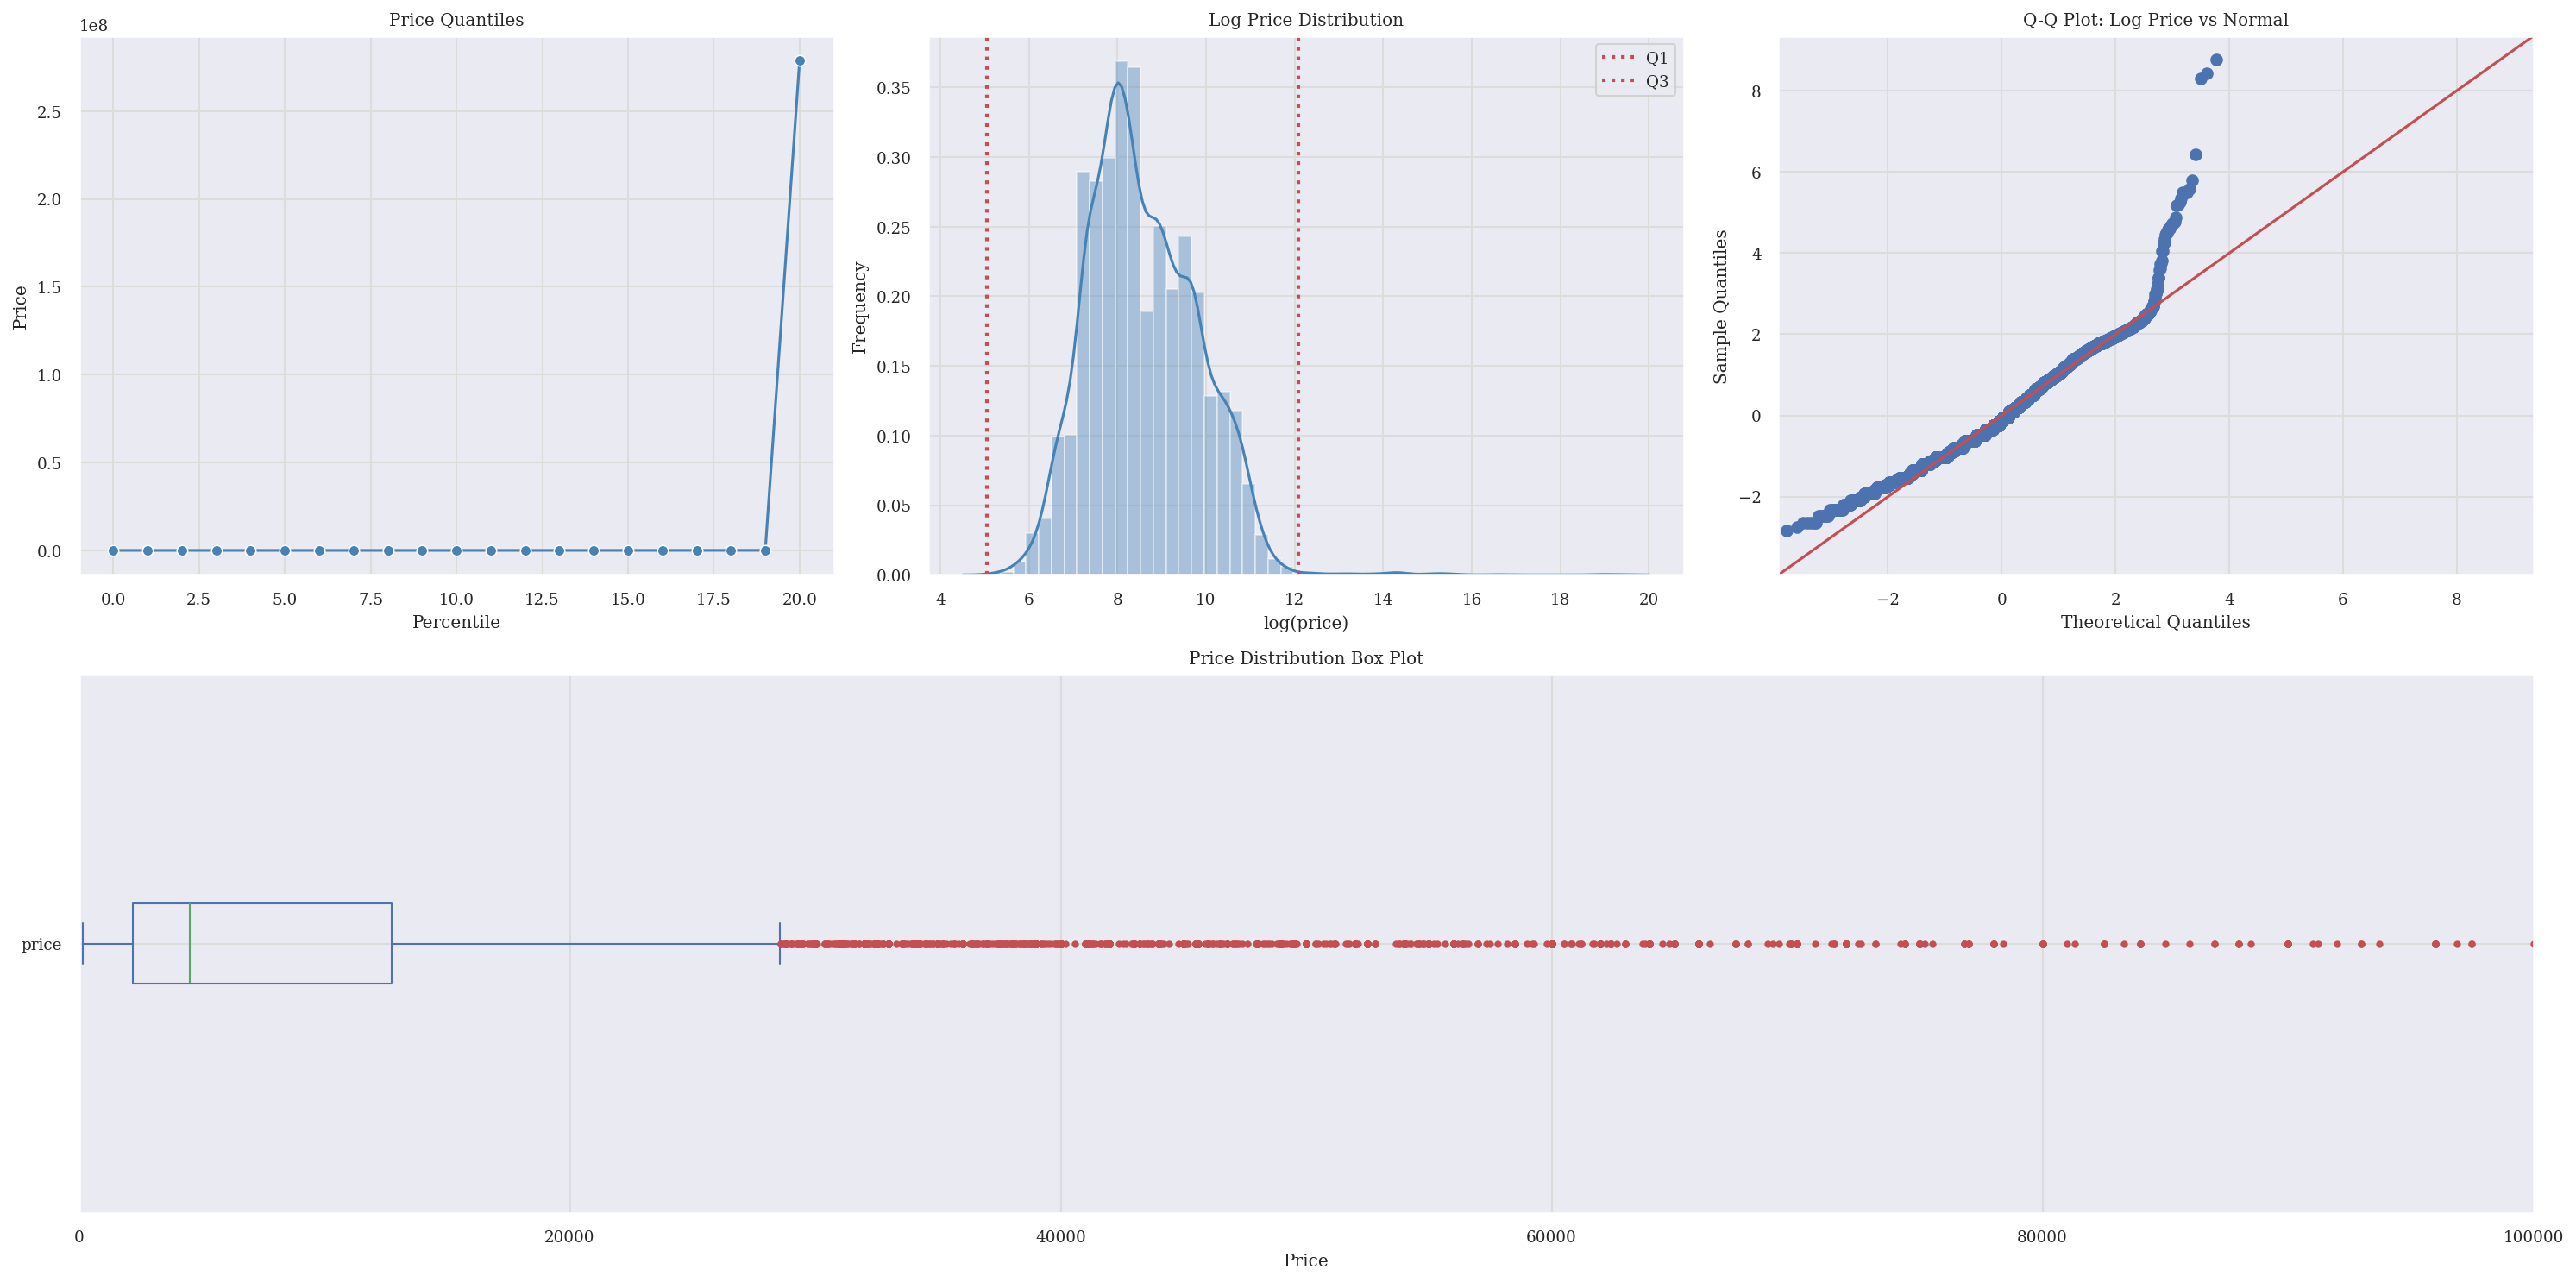

In [ ]:
quantiles = [train_df["price"].quantile(p / 100) for p in range(0, 101, 5)]

fig = plt.figure(num=1, figsize=(20, 10))

# Quantile line plot
plt.subplot2grid((2, 3), (0, 0))
sns.lineplot(x=range(len(quantiles)), y=quantiles, marker="o", color="steelblue")
plt.xlabel("Percentile")
plt.ylabel("Price")
plt.title("Price Quantiles")

# Log price distribution
plt.subplot2grid((2, 3), (0, 1))
sns.distplot(np.log(train_df["price"]), kde=True, color="steelblue")
plt.axvline(x=l1, color="r", linestyle=":", linewidth=2, label="Q1")
plt.axvline(x=l2, color="r", linestyle=":", linewidth=2, label="Q3")
plt.xlabel("log(price)")
plt.ylabel("Frequency")
plt.title("Log Price Distribution")
plt.legend()

# Q-Q plot
ax = plt.subplot2grid((2, 3), (0, 2))
sm.qqplot(np.log1p(train_df["price"]), stats.norm, fit=True, line="45", ax=ax)
plt.title("Q-Q Plot: Log Price vs Normal")

# Box plot
plt.subplot2grid((2, 3), (1, 0), colspan=3)
red = dict(markerfacecolor="r", markeredgecolor="r", marker=".")
train_df["price"].plot(kind="box", vert=False, flierprops=red, xlim=(0, 100_000))
plt.xlabel("Price")
plt.title("Price Distribution Box Plot")

plt.tight_layout()
plt.show()


In [92]:
train_outliers = train_df[
    (np.log(train_df["price"]) < l1) | (np.log(train_df["price"]) > l2)
]

eval_outliers = eval_df[
    (np.log(eval_df["price"]) < l1) | (np.log(eval_df["price"]) > l2)
]

logger.info(
    f"{len(train_outliers)} outliers in training set and {len(eval_outliers)} outliers in evaluation set."
)

[2026-01-11 12:14:24,953: INFO: 816585731: 45 outliers in training set and 16 outliers in evaluation set.]


In [93]:
train_df = train_df.drop(index=train_outliers.index)
eval_df = eval_df.drop(index=eval_outliers.index)

Text(0.5, 1.0, 'Price distribution of training set')

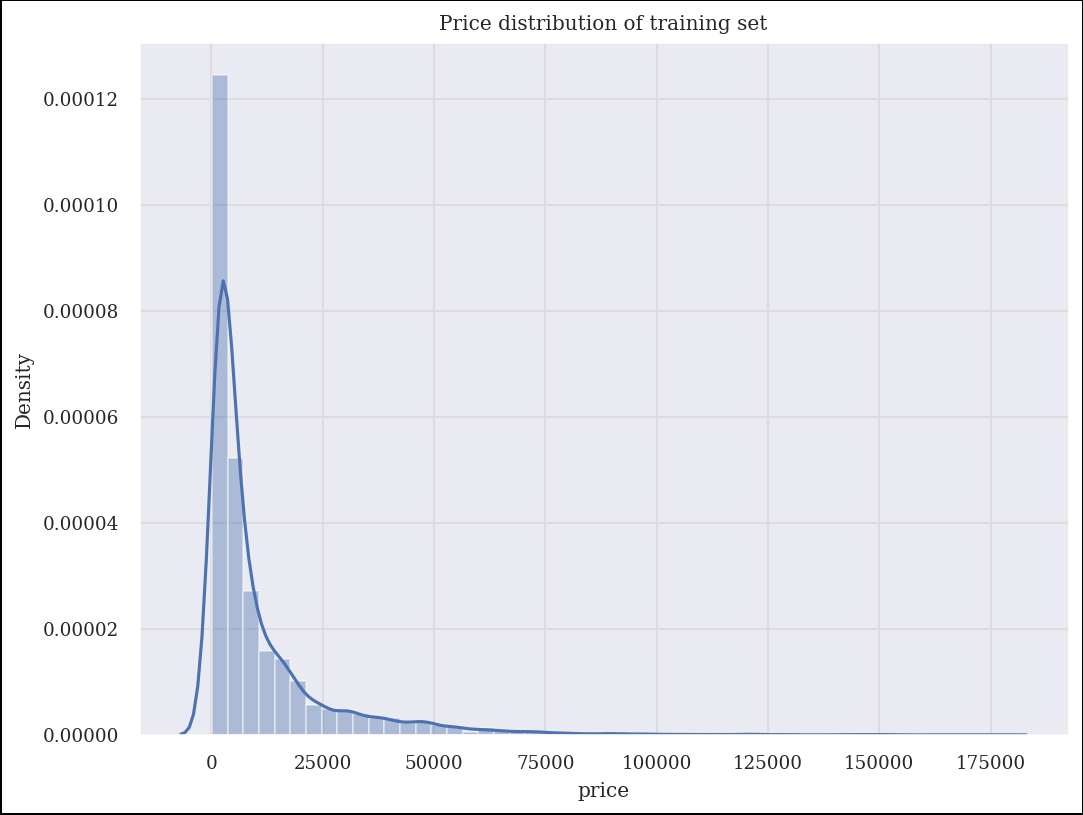

In [94]:
plt.figure(figsize=(8, 6), linewidth=1)
sns.distplot(train_df.price)
plt.title("Price distribution of training set")

# Extra Cleaning


In [96]:
train_df.Condition.value_counts()

Condition
Newly-Built    6129
Fairly Used    5699
Renovated       553
Old              79
Name: count, dtype: int64

In [97]:
train_df.Condition = train_df.Condition.map(
    {
        "Newly-Built": "New",
        "Fairly Used": "Used",
        "Old": "Used",
        "Renovated": "Renovated",
    }
)
eval_df.Condition = eval_df.Condition.map(
    {
        "Newly-Built": "New",
        "Fairly Used": "Used",
        "Old": "Used",
        "Renovated": "Renovated",
    }
)

# Feature Selection

In [98]:
feature_columns = [
    "url",
    "house_type",
    "bathrooms",
    "bedrooms",
    "price",
    "locality",
    "lat",
    "lng",
    "Condition",
    "Furnishing",
    "24-hour Electricity",
    "Air Conditioning",
    "Apartment",
    "Balcony",
    "Chandelier",
    "Dining Area",
    "Dishwasher",
    "Hot Water",
    "Kitchen Cabinets",
    "Kitchen Shelf",
    "Microwave",
    "Pop Ceiling",
    "Pre-Paid Meter",
    "Refrigerator",
    "TV",
    "Tiled Floor",
    "Wardrobe",
    "Wi-Fi",
]

In [99]:
train_df = train_df[feature_columns]
eval_df = eval_df[feature_columns]

train_df = train_df.dropna(subset=feature_columns)
eval_df = eval_df.dropna(subset=feature_columns)

In [100]:
def rename_cols(df):
    for col in df.columns.to_list():
        df.rename(
            columns={col: col.lower().replace(" ", "_").replace("-", "_")}, inplace=True
        )
    return df

In [101]:
train_df = rename_cols(train_df)
eval_df = rename_cols(eval_df)

In [102]:
train_df.to_csv("../artifacts/data/02-preprocessed/train_df.csv", index=False)
eval_df.to_csv("../artifacts/data/02-preprocessed/eval_df.csv", index=False)

logger.info(
    f"✅ Cleaning complete, final train size: {train_df.shape}, eval size: {eval_df.shape}"
)

[2026-01-11 12:14:25,748: INFO: 2474779596: ✅ Cleaning complete, final train size: (12460, 28), eval size: (3111, 28)]
